In [10]:
%pip install -q langchain langchain_core langchain_groq langchain_community langgraph gradio pydantic python-dotenv grandalf

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: C:\Users\My PC\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import os
import logging
from typing import TypedDict, Annotated, List, Literal, Optional
from datetime import date

from pydantic import BaseModel, Field, ValidationError
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image, Markdown

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
log = logging.getLogger("trip-planner")

In [3]:
class PlannerState(TypedDict, total=False):
    messages: Annotated[List[HumanMessage | AIMessage], "the messages in the conversation"]
    city: str
    interests: List[str]
    budget: str            # e.g. "low", "medium", "luxury"
    travel_style: str      # e.g. "relaxed", "adventurous", "family-friendly"
    days: int              # number of trip days (1 = day trip)
    travel_date: str       # ISO date string, optional
    dietary: str           # e.g. "vegetarian", "halal", "none"
    itinerary: str         # current draft
    feedback: str          # user feedback for refinement
    revisions: int         # how many refinement loops done
    approved: bool         # whether user approved final itinerary

In [5]:
# Load API key from environment (NEVER hard-code secrets in notebooks).
# Set it once in your shell:   export GROQ_API_KEY="sk-..."
# Or create a .env file with:  GROQ_API_KEY=sk-...
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

import getpass
if not os.getenv("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your GROQ_API_KEY: ")

from langchain_groq import ChatGroq

llm = ChatGroq(
    temperature=0.3,
    model_name="llama-3.3-70b-versatile",
    max_retries=3,
    timeout=60,
)

In [6]:
SYSTEM_PROMPT = (
    "You are an expert travel concierge. You create detailed, realistic, time-blocked itineraries. "
    "Always respect the user's budget, travel style, dietary needs and number of days. "
    "For each activity include: time, place name, short description, estimated cost (in USD), "
    "and a practical tip. Prefer walkable clusters to minimise transit. End with a short "
    "'Packing & Logistics' section."
)

itinerary_prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    ("human",
     "Plan a {days}-day trip to {city}.\n"
     "Travel date: {travel_date}\n"
     "Interests: {interests}\n"
     "Budget: {budget}\n"
     "Travel style: {travel_style}\n"
     "Dietary preferences: {dietary}\n\n"
     "Return the itinerary as Markdown with one section per day."),
])

refine_prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM_PROMPT),
    ("human",
     "Here is the current itinerary:\n\n{itinerary}\n\n"
     "The user gave this feedback:\n\"{feedback}\"\n\n"
     "Revise the itinerary to address the feedback. Keep what already works. "
     "Return the full updated Markdown itinerary."),
])

In [7]:
MAX_REVISIONS = 3


def _ensure_messages(state: PlannerState) -> List:
    return state.get("messages", []) or []


def collect_preferences(state: PlannerState) -> PlannerState:
    """Validate / fill in defaults for required preferences."""
    city = (state.get("city") or "").strip()
    if not city:
        raise ValueError("City is required.")

    interests = state.get("interests") or []
    if isinstance(interests, str):
        interests = [i.strip() for i in interests.split(",") if i.strip()]
    if not interests:
        interests = ["general sightseeing"]

    days = int(state.get("days") or 1)
    days = max(1, min(days, 14))  # clamp 1..14

    updates = {
        "city": city,
        "interests": interests,
        "days": days,
        "budget": state.get("budget") or "medium",
        "travel_style": state.get("travel_style") or "balanced",
        "dietary": state.get("dietary") or "none",
        "travel_date": state.get("travel_date") or str(date.today()),
        "revisions": state.get("revisions", 0),
        "approved": False,
    }
    log.info("Preferences collected: %s", {k: updates[k] for k in ("city", "days", "budget", "travel_style")})
    return {**state, **updates,
            "messages": _ensure_messages(state) + [
                HumanMessage(content=f"Plan {days}-day trip to {city} | interests={interests}")
            ]}


def create_itinerary(state: PlannerState) -> PlannerState:
    log.info("Generating itinerary for %s (%d day(s))", state["city"], state["days"])
    msgs = itinerary_prompt.format_messages(
        city=state["city"],
        days=state["days"],
        travel_date=state["travel_date"],
        interests=", ".join(state["interests"]),
        budget=state["budget"],
        travel_style=state["travel_style"],
        dietary=state["dietary"],
    )
    response = llm.invoke(msgs)
    return {**state,
            "itinerary": response.content,
            "messages": _ensure_messages(state) + [AIMessage(content=response.content)]}


def refine_itinerary(state: PlannerState) -> PlannerState:
    feedback = (state.get("feedback") or "").strip()
    if not feedback:
        return {**state, "approved": True}
    log.info("Refining itinerary (revision %d) with feedback: %s",
             state.get("revisions", 0) + 1, feedback[:80])
    msgs = refine_prompt.format_messages(itinerary=state["itinerary"], feedback=feedback)
    response = llm.invoke(msgs)
    return {**state,
            "itinerary": response.content,
            "revisions": state.get("revisions", 0) + 1,
            "feedback": "",
            "messages": _ensure_messages(state) + [
                HumanMessage(content=f"Feedback: {feedback}"),
                AIMessage(content=response.content),
            ]}


def should_refine(state: PlannerState) -> Literal["refine_itinerary", "__end__"]:
    """Conditional edge: loop back for refinement if feedback is given and budget remains."""
    if state.get("approved"):
        return END
    if state.get("feedback") and state.get("revisions", 0) < MAX_REVISIONS:
        return "refine_itinerary"
    return END

In [8]:
workflow = StateGraph(PlannerState)
workflow.add_node("collect_preferences", collect_preferences)
workflow.add_node("create_itinerary", create_itinerary)
workflow.add_node("refine_itinerary", refine_itinerary)

workflow.set_entry_point("collect_preferences")
workflow.add_edge("collect_preferences", "create_itinerary")
workflow.add_conditional_edges("create_itinerary", should_refine,
                               {"refine_itinerary": "refine_itinerary", END: END})
workflow.add_conditional_edges("refine_itinerary", should_refine,
                               {"refine_itinerary": "refine_itinerary", END: END})

app = workflow.compile()

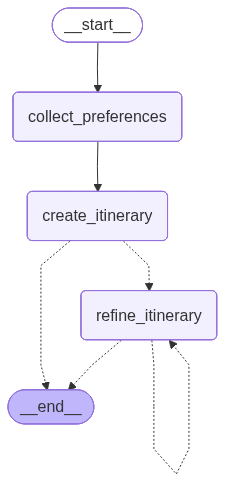

In [11]:
try:
    display(Image(app.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)))
except Exception as e:
    log.warning("Mermaid render failed (%s). Falling back to ASCII:", e)
    print(app.get_graph().draw_ascii())

In [12]:
def travel_planner_cli():
    """Interactive CLI runner that uses the LangGraph workflow."""
    city = input("City: ").strip()
    interests = input("Interests (comma-separated): ").strip()
    days = input("Number of days [1]: ").strip() or "1"
    budget = input("Budget (low/medium/luxury) [medium]: ").strip() or "medium"
    style = input("Travel style (relaxed/adventurous/family) [relaxed]: ").strip() or "relaxed"
    dietary = input("Dietary preferences [none]: ").strip() or "none"

    try:
        final_state = app.invoke({
            "city": city,
            "interests": interests,
            "days": int(days),
            "budget": budget,
            "travel_style": style,
            "dietary": dietary,
            "messages": [],
        })
    except (ValueError, ValidationError) as e:
        print(f"Invalid input: {e}")
        return

    display(Markdown(f"### Itinerary for {final_state['city']}\n\n{final_state['itinerary']}"))
    return final_state

In [13]:
# Uncomment to try the interactive CLI version:
travel_planner_cli()

2026-05-22 12:20:14,212 | INFO | Preferences collected: {'city': 'Hubli', 'days': 3, 'budget': 'medium', 'travel_style': 'family'}
2026-05-22 12:20:14,214 | INFO | Generating itinerary for Hubli (3 day(s))
2026-05-22 12:20:17,823 | INFO | HTTP Request: POST https://api.groq.com/openai/v1/chat/completions "HTTP/1.1 200 OK"


### Itinerary for Hubli

### Day 1: 2026-05-22
* 8:00 AM, **Santosh Hotel**, Have a delicious non-veg breakfast at this local favorite, try their popular dishes like idli, vada, and dosa. ($5)
	+ Practical tip: Reach early to avoid the rush.
* 10:00 AM, **Hubli Market**, Explore the local market to get a taste of the city's food culture, try some street food like chaat items and fresh fruits. ($3)
	+ Practical tip: Be sure to try the local specialties like mirchi bhaji.
* 1:00 PM, **Kamath Yatri Nivas**, Savor a non-veg lunch at this restaurant, known for its traditional Karnataka cuisine. ($10)
	+ Practical tip: Try their signature dish, the chicken sagu.
* 3:30 PM, **Chandramouleshwara Temple**, Take a short walk to this ancient temple, a great place to relax and unwind after lunch. (free)
	+ Practical tip: Remove your shoes before entering the temple premises.
* 7:00 PM, **Nagarabhavi**, Enjoy a non-veg dinner at one of the local eateries, try some popular dishes like biryani and kebabs. ($8)
	+ Practical tip: Try to avoid eating at very crowded places.

### Day 2: 2026-05-23
* 9:00 AM, **Gadag Road**, Visit the local bakeries and try some freshly baked non-veg pastries and bread. ($4)
	+ Practical tip: Try the local specialty, the benne dose.
* 11:30 AM, **Unkal Lake**, Take a leisurely walk around the lake, a great place for a family outing. (free)
	+ Practical tip: Be mindful of the surroundings and keep the place clean.
* 1:30 PM, **Basaveshwar Khanavali**, Have a non-veg lunch at this popular restaurant, known for its North Indian cuisine. ($12)
	+ Practical tip: Try their signature dish, the butter chicken.
* 3:30 PM, **Hubli-Dharwad Municipal Corporation**, Explore the local municipal market, a great place to try some street food and local snacks. ($5)
	+ Practical tip: Try the local fruit juices and chaat items.
* 7:30 PM, **Keshav Nagar**, Enjoy a non-veg dinner at one of the local eateries, try some popular dishes like tandoori chicken and naan. ($10)
	+ Practical tip: Try to avoid eating at very crowded places.

### Day 3: 2026-05-24
* 8:30 AM, **Sai International**, Have a non-veg breakfast at this restaurant, known for its South Indian cuisine. ($6)
	+ Practical tip: Try their signature dish, the masala dose.
* 10:30 AM, **Dharwad**, Take a short trip to Dharwad, a nearby city known for its food culture, try some local specialties like peda and milk sweets. ($15)
	+ Practical tip: Try to avoid traveling during peak hours.
* 1:30 PM, **Taj Restaurant**, Have a non-veg lunch at this popular restaurant, known for its Mughlai cuisine. ($15)
	+ Practical tip: Try their signature dish, the biryani.
* 3:30 PM, **Glass House**, Take a short walk to this beautiful garden, a great place to relax and unwind after lunch. (free)
	+ Practical tip: Be mindful of the surroundings and keep the place clean.
* 6:00 PM, **Hubli Railway Station**, Depart from Hubli, bringing back memories of the delicious food and great family time. 
	+ Practical tip: Check the train schedule in advance to avoid any last-minute hassles.

### Packing & Logistics
* Pack comfortable clothing and shoes for walking.
* Carry a water bottle and stay hydrated throughout the day.
* Be sure to check the weather forecast before traveling and pack accordingly.
* Book your accommodations and restaurants in advance to avoid any last-minute hassles.
* Don't forget to carry your camera to capture the memories of your trip.

{'messages': [HumanMessage(content="Plan 3-day trip to Hubli | interests=['Food']", additional_kwargs={}, response_metadata={}),
  AIMessage(content="### Day 1: 2026-05-22\n* 8:00 AM, **Santosh Hotel**, Have a delicious non-veg breakfast at this local favorite, try their popular dishes like idli, vada, and dosa. ($5)\n\t+ Practical tip: Reach early to avoid the rush.\n* 10:00 AM, **Hubli Market**, Explore the local market to get a taste of the city's food culture, try some street food like chaat items and fresh fruits. ($3)\n\t+ Practical tip: Be sure to try the local specialties like mirchi bhaji.\n* 1:00 PM, **Kamath Yatri Nivas**, Savor a non-veg lunch at this restaurant, known for its traditional Karnataka cuisine. ($10)\n\t+ Practical tip: Try their signature dish, the chicken sagu.\n* 3:30 PM, **Chandramouleshwara Temple**, Take a short walk to this ancient temple, a great place to relax and unwind after lunch. (free)\n\t+ Practical tip: Remove your shoes before entering the temp

In [ ]:
# --- Gradio UI: streaming chat-style trip planner with refinement loop ---

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 MB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 321.9/321.9 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.8/94.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 464.1/464.1 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 82.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.2 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.27.1
    Uninstalling huggingface-hub-0.27.1:
      Successfully uninstalled huggingface-hub-0.27.1


In [ ]:
import gradio as gr


def _stream_itinerary(state: PlannerState):
    """Yield itinerary text incrementally from Groq."""
    msgs = itinerary_prompt.format_messages(
        city=state["city"],
        days=state["days"],
        travel_date=state["travel_date"],
        interests=", ".join(state["interests"]),
        budget=state["budget"],
        travel_style=state["travel_style"],
        dietary=state["dietary"],
    )
    chunks = []
    for chunk in llm.stream(msgs):
        chunks.append(chunk.content or "")
        yield "".join(chunks)


def _stream_refine(state: PlannerState, feedback: str):
    msgs = refine_prompt.format_messages(itinerary=state["itinerary"], feedback=feedback)
    chunks = []
    for chunk in llm.stream(msgs):
        chunks.append(chunk.content or "")
        yield "".join(chunks)


def plan_trip(city, interests, days, budget, style, dietary, travel_date, ui_state):
    if not city or not city.strip():
        yield "Please enter a city.", ui_state
        return
    try:
        state = collect_preferences({
            "city": city,
            "interests": interests,
            "days": int(days),
            "budget": budget,
            "travel_style": style,
            "dietary": dietary,
            "travel_date": travel_date or str(date.today()),
            "messages": [],
        })
    except Exception as e:
        yield f"**Error:** {e}", ui_state
        return

    partial = ""
    for partial in _stream_itinerary(state):
        yield partial, ui_state
    state["itinerary"] = partial
    yield partial, state


def refine_trip(feedback, ui_state):
    if not ui_state or not ui_state.get("itinerary"):
        yield "Generate an itinerary first.", ui_state
        return
    if not feedback or not feedback.strip():
        yield ui_state["itinerary"], ui_state
        return
    if ui_state.get("revisions", 0) >= MAX_REVISIONS:
        yield ui_state["itinerary"] + f"\n\n_Reached max refinement rounds ({MAX_REVISIONS})._", ui_state
        return

    partial = ""
    for partial in _stream_refine(ui_state, feedback):
        yield partial, ui_state
    ui_state["itinerary"] = partial
    ui_state["revisions"] = ui_state.get("revisions", 0) + 1
    yield partial, ui_state


with gr.Blocks(theme=gr.themes.Soft(primary_hue="emerald"), title="AI Trip Planner") as demo:
    gr.Markdown("# 🗺️ AI Trip Planner\nPowered by LangGraph + Groq Llama 3.3")
    ui_state = gr.State({})

    with gr.Row():
        with gr.Column(scale=1):
            city = gr.Textbox(label="City", placeholder="e.g. Kyoto")
            interests = gr.Textbox(label="Interests (comma-separated)",
                                   placeholder="temples, ramen, gardens")
            days = gr.Slider(1, 14, value=1, step=1, label="Number of days")
            travel_date = gr.Textbox(label="Travel date (YYYY-MM-DD)",
                                     value=str(date.today()))
            budget = gr.Radio(["low", "medium", "luxury"], value="medium", label="Budget")
            style = gr.Radio(["relaxed", "balanced", "adventurous", "family-friendly"],
                             value="balanced", label="Travel style")
            dietary = gr.Textbox(label="Dietary preferences",
                                 placeholder="vegetarian, halal, none", value="none")
            plan_btn = gr.Button("Generate itinerary", variant="primary")

            gr.Examples(
                examples=[
                    ["Kyoto", "temples, ramen, gardens", 2, "medium", "relaxed", "vegetarian"],
                    ["Barcelona", "architecture, tapas, beach", 3, "medium", "balanced", "none"],
                    ["Reykjavik", "northern lights, hiking, hot springs", 4, "luxury", "adventurous", "none"],
                ],
                inputs=[city, interests, days, budget, style, dietary],
                label="Try an example",
            )

        with gr.Column(scale=2):
            itinerary_out = gr.Markdown(label="Itinerary",
                                        value="_Your itinerary will appear here…_")
            with gr.Accordion("Refine itinerary", open=True):
                feedback = gr.Textbox(label="What would you change?",
                                      placeholder="Make day 2 more relaxed, swap dinner for street food…")
                refine_btn = gr.Button("Refine")

    plan_btn.click(
        plan_trip,
        inputs=[city, interests, days, budget, style, dietary, travel_date, ui_state],
        outputs=[itinerary_out, ui_state],
    )
    refine_btn.click(
        refine_trip,
        inputs=[feedback, ui_state],
        outputs=[itinerary_out, ui_state],
    )

if __name__ == "__main__":
    demo.launch(share=False)
else:
    demo.launch(share=False, inline=True)

C:\Users\My PC\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\My PC\AppData\Local\Temp\ipykernel_10020\656699063.py:74: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="emerald"), title="AI Trip Planner") as demo:


* Running on local URL:  http://127.0.0.1:7860


2026-05-22 12:20:43,608 | INFO | HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-initiated-analytics "HTTP/1.1 200 OK"
2026-05-22 12:20:43,754 | INFO | HTTP Request: GET http://127.0.0.1:7860/gradio_api/startup-events "HTTP/1.1 200 OK"
2026-05-22 12:20:43,770 | INFO | HTTP Request: HEAD http://127.0.0.1:7860/ "HTTP/1.1 200 OK"


* To create a public link, set `share=True` in `launch()`.


2026-05-22 12:20:44,008 | INFO | HTTP Request: HEAD https://huggingface.co/api/telemetry/https%3A/api.gradio.app/gradio-launched-telemetry "HTTP/1.1 200 OK"
2026-05-22 12:20:44,439 | INFO | HTTP Request: GET https://api.gradio.app/pkg-version "HTTP/1.1 200 OK"
